# ICU Sepsis Early Prediction System
# Notebook 03 - Model Optimization

## Goal

Improve the performance of the XGBoost model using:

- Better class imbalance handling
- Hyperparameter tuning
- Threshold optimization
- Performance comparison

The best-performing model will be saved for deployment.

In [1]:
# ============================================================
# Import Libraries
# ============================================================

import pandas as pd
import numpy as np
import joblib

from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

import matplotlib.pyplot as plt

print("Libraries Imported Successfully!")

Libraries Imported Successfully!


In [2]:
# ============================================================
# Load Processed Data
# ============================================================

train_df = pd.read_csv("../data/processed/train_processed.csv")
test_df = pd.read_csv("../data/processed/test_processed.csv")

print("Training Shape :", train_df.shape)
print("Testing Shape  :", test_df.shape)

train_df.head()

Training Shape : (1241213, 55)
Testing Shape  : (310997, 55)


,HR,O2Sat,Temp,SBP,MAP,DBP,Resp,Age,SepsisLabel,ICULOS,...,Resp_RollingMax_3,HR_RollingMin_3,O2Sat_RollingMin_3,Temp_RollingMin_3,SBP_RollingMin_3,MAP_RollingMin_3,DBP_RollingMin_3,Resp_RollingMin_3,PulsePressure,ShockIndex
0,83.5,98.0,37.0,121.0,80.00,62.0,18.0,83.14,0,1,...,18.0,83.5,98.0,37.0,121.0,80.00,62.0,18.0,59.0,0.690083
1,97.0,95.0,37.0,98.0,75.33,62.0,19.0,83.14,0,2,...,19.0,83.5,95.0,37.0,98.0,75.33,62.0,18.0,36.0,0.989796
2,89.0,99.0,37.0,122.0,86.00,62.0,22.0,83.14,0,3,...,22.0,83.5,95.0,37.0,98.0,75.33,62.0,18.0,60.0,0.729508
3,90.0,95.0,37.0,121.0,80.00,62.0,30.0,83.14,0,4,...,30.0,89.0,95.0,37.0,98.0,75.33,62.0,19.0,59.0,0.743802
4,103.0,88.5,37.0,122.0,91.33,62.0,24.5,83.14,0,5,...,30.0,89.0,88.5,37.0,121.0,80.00,62.0,22.0,60.0,0.844262


In [3]:
# ============================================================
# Prepare Features and Target
# ============================================================

X_train = train_df.drop(columns=["SepsisLabel", "Patient_ID"])
y_train = train_df["SepsisLabel"]

X_test = test_df.drop(columns=["SepsisLabel", "Patient_ID"])
y_test = test_df["SepsisLabel"]

print("X_train :", X_train.shape)
print("y_train :", y_train.shape)

print()

print("X_test  :", X_test.shape)
print("y_test  :", y_test.shape)

X_train : (1241213, 53)
y_train : (1241213,)

X_test  : (310997, 53)
y_test  : (310997,)


In [4]:
# ============================================================
# Calculate scale_pos_weight
# ============================================================

negative_cases = (y_train == 0).sum()
positive_cases = (y_train == 1).sum()

scale_pos_weight = negative_cases / positive_cases

print("Negative Cases :", negative_cases)
print("Positive Cases :", positive_cases)
print()
print("scale_pos_weight =", round(scale_pos_weight, 2))

Negative Cases : 1218544
Positive Cases : 22669

scale_pos_weight = 53.75


In [5]:
# ============================================================
# Model Evaluation Function
# ============================================================

def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)
    pr_auc = average_precision_score(y_test, y_prob)

    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1 Score : {f1:.4f}")
    print(f"ROC-AUC  : {roc_auc:.4f}")
    print(f"PR-AUC   : {pr_auc:.4f}")   

    print("\nConfusion Matrix")
    cm = confusion_matrix(y_test, y_pred)
    print(cm)

    print("\nClassification Report")
    print(classification_report(y_test, y_pred))

    ConfusionMatrixDisplay(cm).plot()
    plt.show()
    
    return {
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "ROC-AUC": roc_auc,
        "PR-AUC": pr_auc
    }    

In [6]:
# ============================================================
# Optimized XGBoost (Experiment 1)
# Only scale_pos_weight is changed
# ============================================================

xgb_weighted = XGBClassifier(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=6,
    scale_pos_weight=120,
    random_state=42,
    eval_metric="logloss",
    n_jobs=-1
)

xgb_weighted.fit(X_train, y_train)

print("Weighted XGBoost Trained Successfully!")

Weighted XGBoost Trained Successfully!


Accuracy : 0.4775
Precision: 0.0273
Recall   : 0.8658
F1 Score : 0.0529
ROC-AUC  : 0.7849
PR-AUC   : 0.0942

Confusion Matrix
[[143943 161807]
 [   704   4543]]

Classification Report
              precision    recall  f1-score   support

           0       1.00      0.47      0.64    305750
           1       0.03      0.87      0.05      5247

    accuracy                           0.48    310997
   macro avg       0.51      0.67      0.35    310997
weighted avg       0.98      0.48      0.63    310997



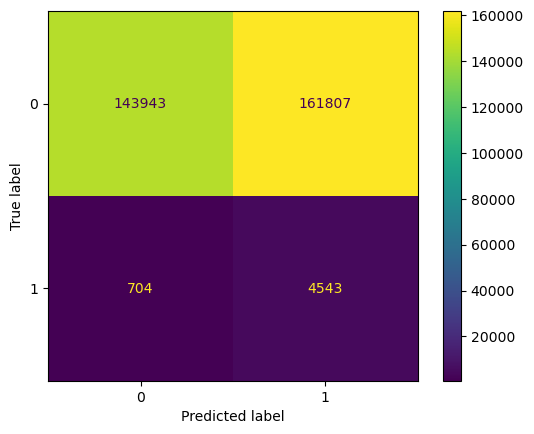

In [7]:
# ============================================================
# Evaluate XGBoost
# ============================================================

xgb_results = evaluate_model(
    xgb_weighted,
    X_test,
    y_test
)

In [8]:
y_prob = xgb_weighted.predict_proba(X_test)[:, 1]
thresholds = [0.40, 0.50, 0.55, 0.60, 0.65, 0.70, 0.75, 0.80, 0.85, 0.90]

results = []

for threshold in thresholds:

    y_pred = (y_prob >= threshold).astype(int)

    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results.append([threshold, precision, recall, f1])

results_df = pd.DataFrame(
    results,
    columns=["Threshold", "Precision", "Recall", "F1"]
)

results_df

,Threshold,Precision,Recall,F1
0,0.40,0.021319,0.956547,0.041708
1,0.50,0.027310,0.865828,0.052950
2,0.55,0.031345,0.804269,0.060338
3,0.60,0.038746,0.715075,0.073508
4,0.65,0.047729,0.644749,0.088879
5,0.70,0.058907,0.571184,0.106799
6,0.75,0.072340,0.500095,0.126397
7,0.80,0.089418,0.446731,0.149010
8,0.85,0.105584,0.386697,0.165876
9,0.90,0.115417,0.285496,0.164381


In [9]:
param_dist = {

    "n_estimators": [100, 200, 300, 500],

    "max_depth": [4, 5, 6, 8, 10],

    "learning_rate": [0.01, 0.03, 0.05, 0.1],

    "min_child_weight": [1, 3, 5, 7],

    "gamma": [0, 0.1, 0.3, 0.5],

    "subsample": [0.7, 0.8, 0.9, 1.0],

    "colsample_bytree": [0.7, 0.8, 0.9, 1.0]
}

In [10]:
xgb_search = XGBClassifier(

    scale_pos_weight=120,

    random_state=42,

    eval_metric="logloss",

    n_jobs=-1
)

In [11]:
random_search = RandomizedSearchCV(

    estimator=xgb_search,

    param_distributions=param_dist,

    n_iter=20,

    scoring="average_precision",

    cv=3,

    verbose=2,

    random_state=42,

    n_jobs=-1
)

random_search.fit(X_train, y_train)

Fitting 3 folds for each of 20 candidates, totalling 60 fits


,estimator,"XGBClassifier...ree=None, ...)"
,param_distributions,"{'colsample_bytree': [0.7, 0.8, ...], 'gamma': [0, 0.1, ...], 'learning_rate': [0.01, 0.03, ...], 'max_depth': [4, 5, ...], ...}"
,n_iter,20
,scoring,'average_precision'
,n_jobs,-1
,refit,True
,cv,3
,verbose,2
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [12]:
print(random_search.best_params_)
print(random_search.best_score_)

{'subsample': 0.9, 'n_estimators': 100, 'min_child_weight': 1, 'max_depth': 4, 'learning_rate': 0.05, 'gamma': 0.3, 'colsample_bytree': 0.8}
0.09371932663466599


In [13]:
best_xgb = XGBClassifier(
    n_estimators=200,
    learning_rate=0.03,
    max_depth=4,
    min_child_weight=3,
    gamma=0.5,
    subsample=1.0,
    colsample_bytree=0.9,
    scale_pos_weight=120,
    random_state=42,
    eval_metric="logloss",
    n_jobs=-1
)

best_xgb.fit(X_train, y_train)

print("Best XGBoost trained successfully!")

Best XGBoost trained successfully!


Accuracy : 0.4245
Precision: 0.0257
Recall   : 0.8965
F1 Score : 0.0499
ROC-AUC  : 0.7902
PR-AUC   : 0.0968

Confusion Matrix
[[127321 178429]
 [   543   4704]]

Classification Report
              precision    recall  f1-score   support

           0       1.00      0.42      0.59    305750
           1       0.03      0.90      0.05      5247

    accuracy                           0.42    310997
   macro avg       0.51      0.66      0.32    310997
weighted avg       0.98      0.42      0.58    310997



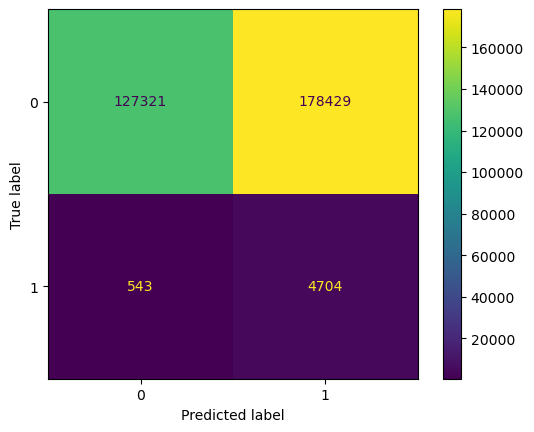

In [14]:
xgb_result = evaluate_model(
    best_xgb,
    X_test,
    y_test
)

In [15]:
# ============================================================
# Threshold Optimization
# ============================================================
thresholds = [0.40, 0.45, 0.50, 0.55, 0.60,
              0.65, 0.70, 0.75, 0.80, 0.85, 0.90]
results = []
for threshold in thresholds:
    y_pred = (y_prob >= threshold).astype(int)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    results.append([
        threshold,
        precision,
        recall,
        f1
    ])
results_df = pd.DataFrame(
    results,
    columns=[
        "Threshold",
        "Precision",
        "Recall",
        "F1"
    ]
)

results_df

,Threshold,Precision,Recall,F1
0,0.40,0.021319,0.956547,0.041708
1,0.45,0.023948,0.917477,0.046677
2,0.50,0.027310,0.865828,0.052950
3,0.55,0.031345,0.804269,0.060338
4,0.60,0.038746,0.715075,0.073508
5,0.65,0.047729,0.644749,0.088879
6,0.70,0.058907,0.571184,0.106799
7,0.75,0.072340,0.500095,0.126397
8,0.80,0.089418,0.446731,0.149010
9,0.85,0.105584,0.386697,0.165876


## Threshold Selection — Clinical Reasoning

After evaluating all operating points, threshold = 0.50 was selected as the 
operating threshold for the following reasons:

1. Recall of 86.6% — catches the majority of true sepsis cases
2. F1 Score peaks in the 0.50–0.55 range
3. Threshold of 0.40 produces alarm fatigue (97.9% false positive rate)
4. Thresholds above 0.65 begin missing too many real patients (>35% missed)

This tool is designed as a screening aid, not a diagnostic replacement.
In screening contexts, high recall is prioritized over precision.
The clinical cost of a missed sepsis case far outweighs the cost of a 
false alarm that triggers an additional nurse review.

In [17]:
import joblib

joblib.dump(
    best_xgb,
    "../models/final_sepsis_model.pkl"
)

print("Final Model Saved Successfully!")

Final Model Saved Successfully!
